<a href="https://colab.research.google.com/github/isoliveira20/POS-IA/blob/main/tech_challenge_02_task_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parâmetros de geração de equipe
- Tipos de task distribuídos conforme perfil realista por stack (ex.: Backend tem mais bugs críticos, frontend mais tarefas planejadas).

- Prioridades variadas, com maior incidência em prioridades média e alta.

- Stacks com presença garantida de todas e distribuição baseada em pesos que refletem a demanda real.

- Complexidade com pontuações variadas de 1 a 8, com cobertura mínima para todas as complexidades.

- Horas estimadas baseadas na complexidade e ajustadas por multiplicadores específicos para cada stack, refletindo diferenças de esforço entre áreas.

- Pelo menos uma task de cada tipo, prioridade, stack e complexidade para assegurar diversidade no conjunto.

min_total_hours: 2270
Stack BE: mínimo estimado de horas = 1240
Stack DB: mínimo estimado de horas = 70
Stack FE: mínimo estimado de horas = 400
Stack MO: mínimo estimado de horas = 140
Stack DS: mínimo estimado de horas = 210
Stack DE: mínimo estimado de horas = 210
{'BE': 0, 'FE': 0, 'DE': 0, 'DS': 0, 'DB': 0, 'MO': 0}
Horas geradas: 2339
Horas por Stack: {'BE': 1247, 'FE': 418, 'DE': 234, 'DS': 223, 'DB': 72, 'MO': 145}
type
Bug               11
Critical Bug       8
Planned Task      58
Spike              7
Technical Debt     9
Unplanned Task     6
dtype: int64
priority
Critical    10
Disaster     4
High        33
Low         28
Medium      24
dtype: int64
stack
BE    50
DB     4
DE    12
DS     7
FE    21
MO     5
dtype: int64
complexity_points
1     5
2     8
3    11
5    18
8    57
dtype: int64
       name            type  type_multiplier  priority  priority_multiplier  \
0    Task_1             Bug             1.50  Critical                 1.50   
1    Task_2    Critical Bug   

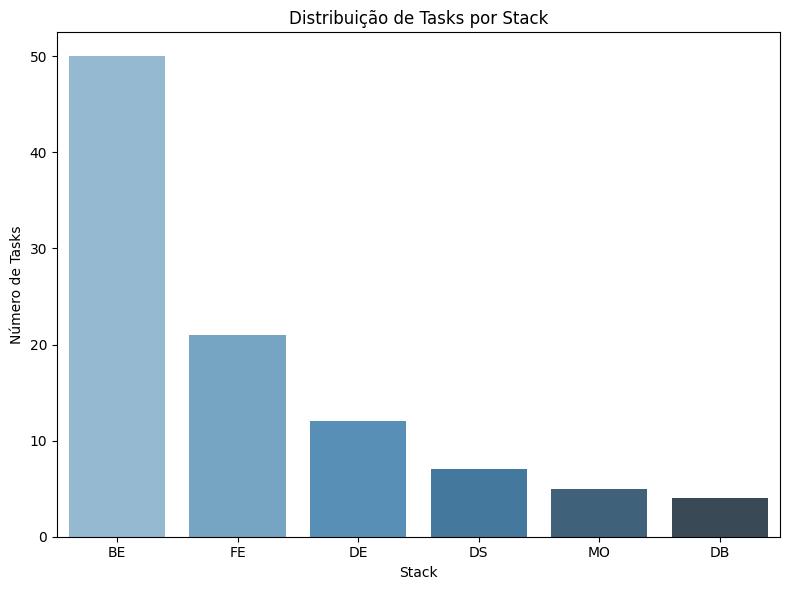

<Figure size 1000x600 with 0 Axes>

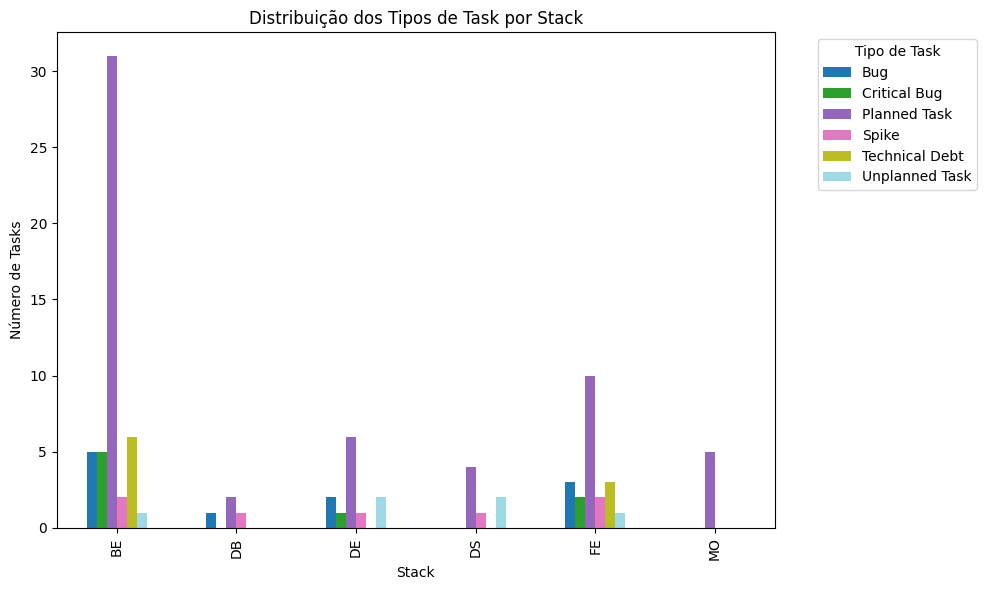

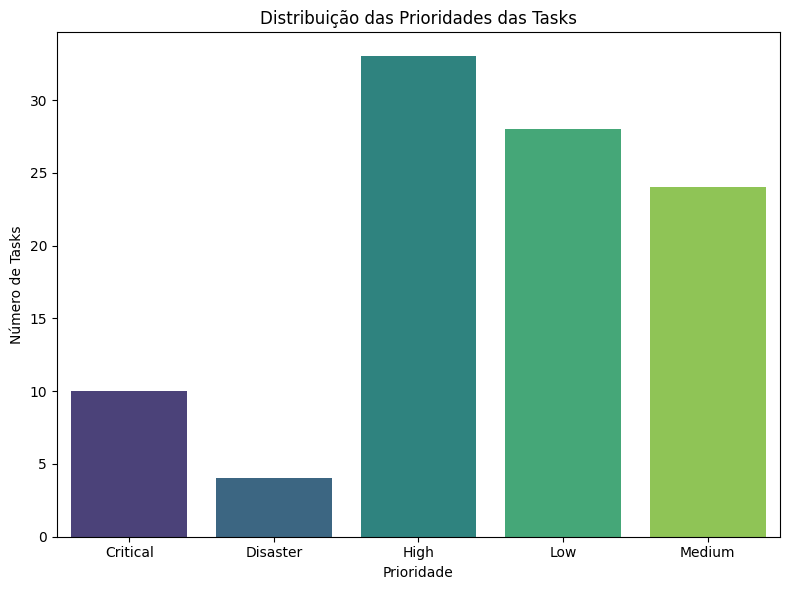

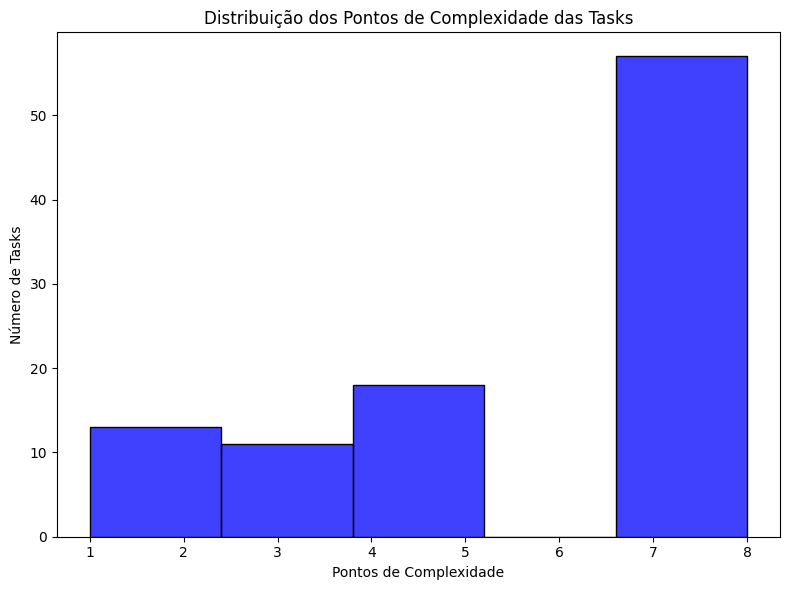

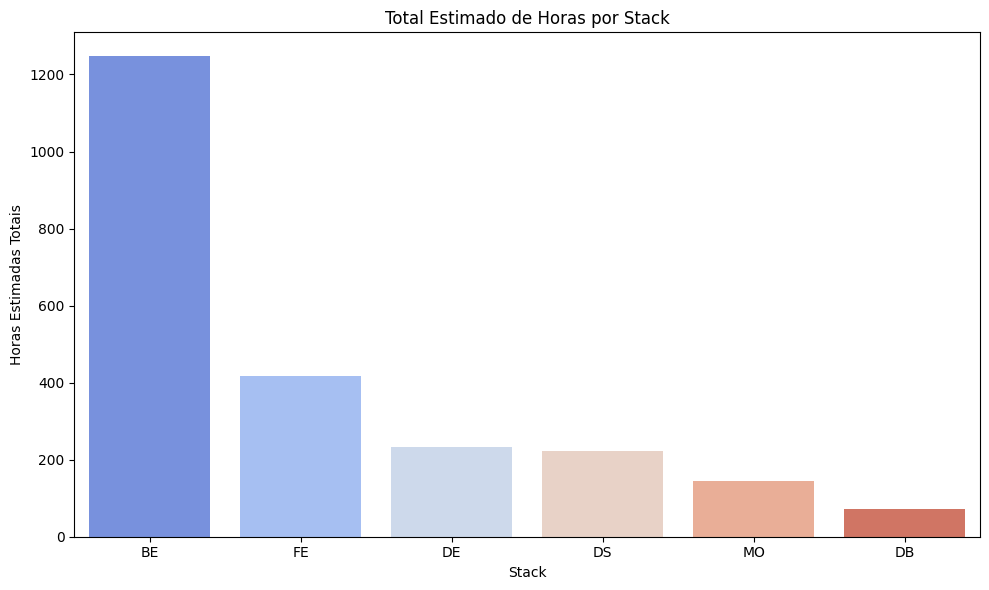

In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

random.seed(42)
np.random.seed(42)

teams_df = pd.read_csv('https://raw.githubusercontent.com/isoliveira20/POS-IA/refs/heads/main/tech_challenge_02/teams_dataset.csv')

level_rules = {
    'Intern':     {'cost_multiplier': 0.5,  'max_daily_hours': 5},
    'Junior':     {'cost_multiplier': 0.75, 'max_daily_hours': 7},
    'Mid-level':  {'cost_multiplier': 1.0,  'max_daily_hours': 7},
    'Senior':     {'cost_multiplier': 1.25, 'max_daily_hours': 7},
    'Specialist': {'cost_multiplier': 1.5,  'max_daily_hours': 7},
}

sprint_days = 10

def calculate_min_hours(level_counts):
    """
    Calcula o total mínimo de horas geral, baseado na quantidade de devs,
    regras de horas máximas diárias por nível, e duração fixa da sprint.
    """
    total = 0

    for level, count in level_counts.items():
        max_hours_per_day = level_rules.get(level, {}).get('max_daily_hours', 7)
        total += count * max_hours_per_day * sprint_days

    return total

level_counts = teams_df['level'].value_counts().to_dict()

min_total_hours = calculate_min_hours(level_counts)

print(f"min_total_hours: {min_total_hours}")

def calculate_min_hours_by_stack(df_teams):
    """
    Calcula o total mínimo de horas para cada stack, baseado na quantidade de devs,
    regras de horas máximas diárias por nível, e duração fixa da sprint.
    """
    # Agrupar por stack e level, contando devs
    counts = df_teams.groupby(['stack', 'level']).size().reset_index(name='count')

    minimo_por_stack = {}

    for stack in df_teams['stack'].unique():
        total_horas_stack = 0
        subset = counts[counts['stack'] == stack]
        for _, row in subset.iterrows():
            nivel = row['level']
            quantidade = row['count']
            max_horas_dia = level_rules.get(nivel, {}).get('max_daily_hours', 7)  # padrão 7 se nível não achar
            total_horas_stack += quantidade * max_horas_dia * sprint_days
        minimo_por_stack[stack] = total_horas_stack

    return minimo_por_stack


min_hours_by_stack = calculate_min_hours_by_stack(teams_df)

for stack, horas in min_hours_by_stack.items():
    print(f"Stack {stack}: mínimo estimado de horas = {horas}")

# Multiplicadores usados para calcular esforço/custo no algoritmo
type_multipliers = {
    'Critical Bug': 2.5,
    'Bug': 1.5,
    'Planned Task': 1,
    'Unplanned Task': 1.25,
    'Technical Debt': 1.25,
    'Spike': 1
}

priority_multipliers = {
    'Disaster': 2,
    'Critical': 1.5,
    'High': 1,
    'Medium': 0.5,
    'Low': 0.25
}

# Pesos para type
type_generation_weights = {
    'Bug': 0.20,
    'Critical Bug': 0.10,
    'Planned Task': 0.40,
    'Unplanned Task': 0.15,
    'Technical Debt': 0.10,
    'Spike': 0.05
}

# Pesos para priority
priority_generation_weights = {
    'Disaster': 0.01,
    'Critical': 0.05,
    'High':  0.45,
    'Medium': 0.35,
    'Low': 0.14
}

type_priority_map = {
    'Critical Bug': ['Disaster', 'Critical'],
    'Bug': ['Critical', 'High', 'Medium'],
    'Planned Task': ['High', 'Medium', 'Low'],
    'Unplanned Task': ['High', 'Medium', 'Low'],
    'Technical Debt': ['Medium', 'Low'],
    'Spike': ['Low'],
}

# Stacks e pesos
stack_weights = {'BE': 4, 'FE': 2, 'DE': 1, 'DS': 1, 'DB': 1, 'MO': 1}
stacks = list(stack_weights.keys())
weighted_stacks = [s for s, w in stack_weights.items() for _ in range(w)]

stack_type_weights = {
    'BE': {'Bug': 0.15, 'Critical Bug': 0.10, 'Planned Task': 0.50, 'Unplanned Task': 0.10, 'Technical Debt': 0.10, 'Spike': 0.05},
    'FE': {'Bug': 0.15, 'Critical Bug': 0.05, 'Planned Task': 0.65, 'Unplanned Task': 0.05, 'Technical Debt': 0.05, 'Spike': 0.05},
    'DE': {'Bug': 0.15, 'Critical Bug': 0.10, 'Planned Task': 0.50, 'Unplanned Task': 0.10, 'Technical Debt': 0.10, 'Spike': 0.05},
    'DS': {'Bug': 0.03, 'Critical Bug': 0.02, 'Planned Task': 0.80, 'Unplanned Task': 0.10, 'Technical Debt': 0.02, 'Spike': 0.02},
    'DB': {'Bug': 0.05, 'Critical Bug': 0.05, 'Planned Task': 0.60, 'Unplanned Task': 0.10, 'Technical Debt': 0.15, 'Spike': 0.05},
    'MO': {'Bug': 0.10, 'Critical Bug': 0.05, 'Planned Task': 0.70, 'Unplanned Task': 0.05, 'Technical Debt': 0.05, 'Spike': 0.05}
}


# Escala de complexidade
complexity_scale = [1, 2, 3, 5, 8]

# Mapeamento de complexidade para faixa de horas estimadas
hours_per_complexity = {
    1: (3, 6),      # 1 ponto
    2: (6, 10),     # 2 pontos
    3: (8, 16),     # 3 pontos
    5: (16, 24),    # 5 pontos
    8: (24, 40)     # 8 pontos
}

stack_hour_multiplier = {
    'BE': 1.0,    # Backend como default
    'FE': 0.85,   # Frontend menos esforço em média
    'DB': 0.90,   # Banco de dados moderado
    'DS': 1.30,   # Data Science demanda mais horas por conta de prototipação e testes
    'DE': 0.95,   # DevOps/Infra na média
    'MO': 1.40    # Mobile com mais tempo por conta da diversidade de dispositivos e testes
}


def generate_task_name(idx):
    return f'Task_{idx+1}'

def create_task(idx, task_type, stack, complexity_points, forced_priority=None):
    min_h, max_h = hours_per_complexity[complexity_points]
    base_hours = random.randint(min_h, max_h)
    adjusted_hours = int(base_hours * stack_hour_multiplier[stack])

    if forced_priority is not None:
        priority = forced_priority
    else:
        possible_priorities = type_priority_map[task_type]
        priority = random.choice(possible_priorities)

    return {
        'name': generate_task_name(idx),
        'type': task_type,
        'type_multiplier': type_multipliers[task_type],
        'priority': priority,
        'priority_multiplier': priority_multipliers[priority],
        'stack': stack,
        'estimated_hours': adjusted_hours,
        'complexity_points': complexity_points
    }

def generate_tasks_balanced_by_team():
    tasks = []
    total_hours = 0
    idx = 0
    fail_count = 0

    stacks_list = stacks
    complexity_list = complexity_scale
    types = list(type_generation_weights.keys())
    priorities = list(priority_generation_weights.keys())

    included_types = set()
    included_priorities = set()
    included_stacks = set()
    included_complexities = set()

    stack_counts = teams_df['stack'].value_counts().to_dict()
    total_devs = sum(stack_counts.values())

    stack_min_hours = min_hours_by_stack.copy()

    stack_current_hours = {stack: 0 for stack in stacks_list}

    print(stack_current_hours)

    def add_task(stack, task_type, complexity_points, forced_priority=None):
        nonlocal total_hours, idx, fail_count
        task = create_task(idx, task_type, stack, complexity_points, forced_priority)

        if stack_current_hours[stack] >= stack_min_hours.get(stack, 0):
            fail_count += 1

            return False

        tasks.append(task)

        total_hours += task['estimated_hours']
        stack_current_hours[stack] += task['estimated_hours']

        included_types.add(task_type)
        included_priorities.add(task['priority'])
        included_stacks.add(stack)
        included_complexities.add(complexity_points)
        idx += 1

        return True

    # Etapas de cobertura
    for task_type in types:
        stack = random.choice(list(stack_counts.keys()))
        complexity = random.choices(complexity_list, weights=[1, 2, 3, 5, 10], k=1)[0]
        add_task(stack, task_type, complexity)

    missing_priorities = [p for p in priorities if p not in included_priorities]
    for priority in missing_priorities:
        possible_types = [t for t, plist in type_priority_map.items() if priority in plist]
        if not possible_types: continue
        task_type = random.choice(possible_types)
        stack = random.choice(list(stack_counts.keys()))
        complexity = random.choices(complexity_list, weights=[1, 2, 3, 5, 10], k=1)[0]
        add_task(stack, task_type, complexity, forced_priority=priority)

    missing_stacks = [s for s in stacks_list if s not in included_stacks]
    for stack in missing_stacks:

        task_type = random.choices(
            list(stack_type_weights[stack].keys()),
            weights=list(stack_type_weights[stack].values()), k=1
        )[0]
        complexity = random.choices(complexity_list, weights=[1, 2, 3, 5, 10], k=1)[0]
        add_task(stack, task_type, complexity)

    missing_complexities = [c for c in complexity_list if c not in included_complexities]
    for complexity in missing_complexities:
        stack = random.choice(list(stack_counts.keys()))
        task_type = random.choices(
            list(stack_type_weights[stack].keys()),
            weights=list(stack_type_weights[stack].values()), k=1
        )[0]

        add_task(stack, task_type, complexity)

    # Loop principal
    stacks_pending = {stack for stack in stacks_list if stack_current_hours[stack] < stack_min_hours.get(stack, 0)}
    while stacks_pending:
        removed_stacks = set()

        for stack in stacks_pending:
            if stack_current_hours[stack] >= stack_min_hours.get(stack, 0):
                removed_stacks.add(stack)
                continue

            # Escolher tipo baseado no peso pra aquela stack
            task_type = random.choices(
                list(stack_type_weights[stack].keys()),
                weights=list(stack_type_weights[stack].values()), k=1
            )[0]

            complexity = random.choices(complexity_list, weights=[1, 2, 3, 5, 10], k=1)[0]

            added = add_task(stack, task_type, complexity)

            if not added:
                removed_stacks.add(stack)

        stacks_pending -= removed_stacks

    print(f"Horas geradas: {total_hours}")
    print(f"Horas por Stack: {stack_current_hours}")

    return pd.DataFrame(tasks)

# Gráficos

# Distribuição dos Tipos de Task
def plot_tasks_count_by_stack(df_tasks):
    plt.figure(figsize=(8,6))
    counts = df_tasks.groupby('stack').size().sort_values(ascending=False)
    sns.barplot(x=counts.index, y=counts.values, palette='Blues_d', hue=counts.index)
    plt.title('Distribuição de Tasks por Stack')
    plt.xlabel('Stack')
    plt.ylabel('Número de Tasks')
    plt.tight_layout()
    plt.show()

# Distribuição dos Tipos de Task por Stack
def plot_task_type_by_stack(df_tasks):
    plt.figure(figsize=(10,6))
    data = df_tasks.groupby(['stack', 'type']).size().unstack(fill_value=0)
    data.plot(kind='bar', stacked=False, colormap='tab20', figsize=(10,6))
    plt.title('Distribuição dos Tipos de Task por Stack')
    plt.xlabel('Stack')
    plt.ylabel('Número de Tasks')
    plt.legend(title='Tipo de Task', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Distribuição das Prioridades das Tasks
def plot_task_priority_distribution(df_tasks):
    plt.figure(figsize=(8,6))
    priority_counts = df_tasks['priority'].value_counts().sort_index()
    sns.barplot(x=priority_counts.index, y=priority_counts.values, palette='viridis', hue=priority_counts.index)
    plt.title('Distribuição das Prioridades das Tasks')
    plt.xlabel('Prioridade')
    plt.ylabel('Número de Tasks')
    plt.tight_layout()
    plt.show()

# Distribuição dos Pontos de Complexidade
def plot_task_complexity_distribution(df_tasks):
    plt.figure(figsize=(8,6))
    sns.histplot(df_tasks['complexity_points'], bins=len(df_tasks['complexity_points'].unique()), kde=False, color='blue')
    plt.title('Distribuição dos Pontos de Complexidade das Tasks')
    plt.xlabel('Pontos de Complexidade')
    plt.ylabel('Número de Tasks')
    plt.tight_layout()
    plt.show()

# Total estimado de horas por Stack
def plot_total_estimated_hours_by_stack(df_tasks):
    plt.figure(figsize=(10,6))
    hours_per_stack = df_tasks.groupby('stack')['estimated_hours'].sum().sort_values(ascending=False)
    sns.barplot(x=hours_per_stack.index, y=hours_per_stack.values, palette='coolwarm', hue=hours_per_stack.index)
    plt.title('Total Estimado de Horas por Stack')
    plt.xlabel('Stack')
    plt.ylabel('Horas Estimadas Totais')
    plt.tight_layout()
    plt.show()

df_tasks = generate_tasks_balanced_by_team()
df_tasks.to_csv('tasks_dataset.csv', index=False)

print(df_tasks.groupby('type').size())
print(df_tasks.groupby('priority').size())
print(df_tasks.groupby('stack').size())
print(df_tasks.groupby('complexity_points').size())
print(df_tasks)

plot_tasks_count_by_stack(df_tasks)
plot_task_type_by_stack(df_tasks)
plot_task_priority_distribution(df_tasks)
plot_task_complexity_distribution(df_tasks)
plot_total_estimated_hours_by_stack(df_tasks)